In [13]:
import os
import pickle
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [32]:
def get_ang_seps(injections_dir):
    
    ang_seps = []
    ecc10s = []
    chirps = []
    etas = []
    chi_as = []
    networks = []
    metric_mms = []
    for i, inj_dir in tqdm(enumerate(sorted(os.listdir(injections_dir)))):

        # Try to load in necessary files
        inj_dir = os.path.join(injections_dir, inj_dir)
        inj_dir = os.path.join(inj_dir, 'outdir/output/')
        try:
            filter_metric_path = os.path.join(inj_dir, 'filter_metric.pkl')
            with open(filter_metric_path, 'rb') as f:
                metric = pickle.load(f)
            inj_path = os.path.join(inj_dir, 'converted_injection_parameters.json')
            with open(inj_path, 'r') as f:
                all_inj_params = json.load(f)
            all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
            peak_path = os.path.join(inj_dir, 'peak_parameters.json')
            with open(peak_path, 'r') as f:
                all_peak_params = json.load(f)
        except:
            continue

        # Save injected parameters and metric mismatch
        ecc10s.append(all_inj_params['posterior_samples']['ecc10'][0])
        chirps.append(all_inj_params['posterior_samples']['chirp_mass'][0])
        etas.append(all_inj_params['posterior_samples']['symmetric_mass_ratio'][0])
        chi_as.append(all_inj_params['posterior_samples']['chi_align'][0])
        networks.append(all_inj_params['posterior_samples']['network'][0])
        metric_mms.append(metric.mismatch)

        # Calculate vectors in dx space
        inj_delta = [all_inj_params['posterior_samples'][dx][0] - metric.x[dx][0] for dx in metric.dx_directions]
        peak_delta = [all_peak_params['posterior_samples'][dx][0] - metric.x[dx][0] for dx in metric.dx_directions]
        inj_dx = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), inj_delta)
        peak_dx = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), peak_delta)

        # Calculate angle between vectors
        inj_dx_norm = inj_dx/np.linalg.norm(inj_dx)
        peak_dx_norm = peak_dx/np.linalg.norm(peak_dx)
        ang = np.arccos(np.dot(inj_dx_norm, peak_dx_norm))
        ang_seps.append(ang)

    return ang_seps, ecc10s, chirps, etas, chi_as, networks, metric_mms

In [46]:
injections_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections'
ang_seps, ecc10s, chirps, etas, chi_as, networks, metric_mms = get_ang_seps(injections_dir)

50it [00:00, 212.45it/s]


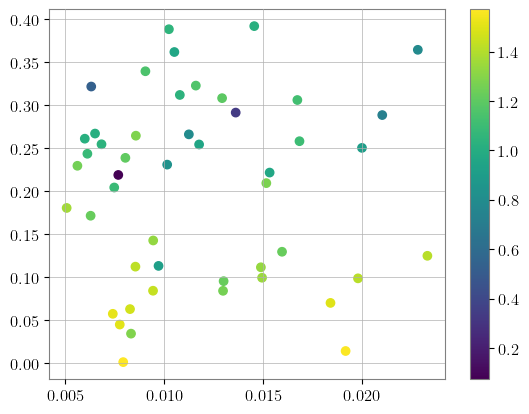

In [47]:
plt.scatter(metric_mms, ecc10s, c=ang_seps)
plt.colorbar()

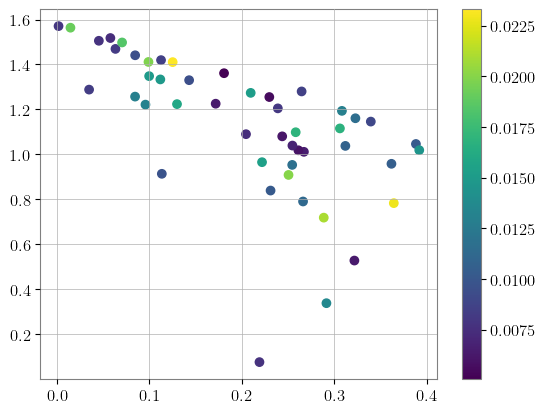

In [48]:
plt.scatter(ecc10s, ang_seps, c=metric_mms)
plt.colorbar()

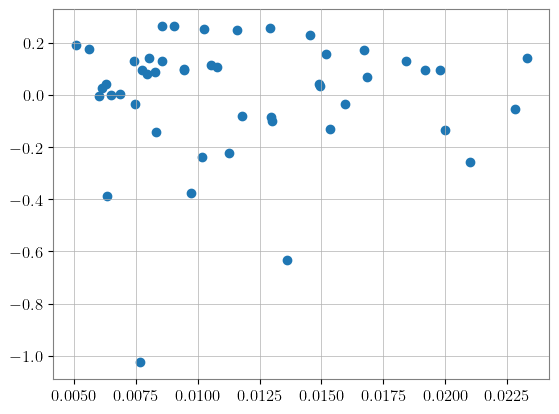

In [49]:
from scipy import optimize

def lin(x, m, c):
    return m*x + c

popt, pcov = optimize.curve_fit(lin, ecc10s, ang_seps)

plt.scatter(metric_mms, ang_seps - lin(np.array(ecc10s), *popt))

In [43]:
popt

array([-1.67253446,  1.51620374])